https://github.com/GFZ/arosics/issues/5

In [1]:
import numpy as np
import xarray as xr
import rioxarray
from arosics import COREG
from geoarray import GeoArray
from rasterio.transform import Affine

# --- Prepare the filtered data -------------------------------------------
stac = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_2024_masked.nc")
masked_stac = stac.Spectral_Temporal_Stack

max_cloud = 9
filtered_data = masked_stac.where(masked_stac.cloud_percentage <= max_cloud, drop=True)
filtered_data = filtered_data.rio.write_crs(masked_stac.crs, inplace=True)

# Get geotransform (assumed to be the same for all dates)
geotransform = filtered_data.spatial_ref.GeoTransform
geotransform = [float(x) for x in geotransform.split()]

# Get the CRS WKT from the spatial_ref of the first time slice
sample_time = filtered_data.time.values[0]
sample_im = filtered_data.sel(time=sample_time)
crs_wkt = sample_im.spatial_ref.crs_wkt

# --- Define a helper function to compute pixel center coordinates ---
def compute_coords(gt, height, width):
    # gt = (origin_x, pixel_width, rotation_x, origin_y, rotation_y, pixel_height)
    origin_x, pixel_width, _, origin_y, _, pixel_height = gt
    x_coords = origin_x + pixel_width * (np.arange(width) + 0.5)
    y_coords = origin_y + pixel_height * (np.arange(height) + 0.5)
    return y_coords, x_coords

# --- Loop over time steps with quiet mode -------------------------------------------
times = filtered_data.time.values
corrected_images = []

# The first image (reference) is not shifted.
im_ref = filtered_data.sel(time=times[0]).transpose("y", "x", "band")
im_ref = im_ref.where(im_ref != 0, np.nan)
height, width, _ = im_ref.shape
y_coords, x_coords = compute_coords(geotransform, height, width)
im_ref = im_ref.assign_coords({"y": ("y", y_coords), "x": ("x", x_coords), "time": times[0]})
corrected_images.append(im_ref)

current_reference = im_ref
band_names = corrected_images[0].band.values 

for i, t in enumerate(times[1:], start=1):
    print(f"Processing time: {t.astype('datetime64[D]')} ({i}/{len(times)-1})")
    im_target = filtered_data.sel(time=t).transpose("y", "x", "band")
    
    # Create GeoArray objects with the same geotransform & CRS
    ref_geoArr = GeoArray(
        current_reference.values,
        geotransform=geotransform,
        projection=crs_wkt
    )
    tgt_geoArr = GeoArray(
        im_target.values,
        geotransform=geotransform,
        projection=crs_wkt
    )
    









    # --- In your loop, replace the COREG call with the following block:

    # Function to compute bounds from a geotransform and image dimensions
    def get_bounds_from_gt(gt, height, width):
        y_coords, x_coords = compute_coords(gt, height, width)
        left = np.min(x_coords)
        right = np.max(x_coords)
        bottom = np.min(y_coords)
        top = np.max(y_coords)
        return left, bottom, right, top

    # Assume default window size in map units is 250 (so half is 125)
    window_size = 250
    half_window = window_size / 2.0

    # Get the bounding box of the target image using the original geotransform.
    # (Assuming im_target has the same dimensions as the reference)
    height_target, width_target, _ = im_target.shape
    left, bottom, right, top = get_bounds_from_gt(geotransform, height_target, width_target)
    center_wp = ((left + right) / 2.0, (bottom + top) / 2.0)

    # Define alternative window positions (in map coordinates)
    alternative_wps = [
        center_wp,  # default center
        (center_wp[0], top - half_window),      # North: window's top edge touches top bound
        (right - half_window, center_wp[1]),      # East: window's right edge touches right bound
        (left + half_window, center_wp[1]),       # West: window's left edge touches left bound
        (center_wp[0], bottom + half_window),     # South: window's bottom edge touches bottom bound
        (right - half_window, top - half_window),   # Northeast: top-right corner
        (right - half_window, bottom + half_window),# Southeast: bottom-right corner
        (left + half_window, bottom + half_window), # Southwest: bottom-left corner
        (left + half_window, top - half_window)     # Northwest: top-left corner
    ]

    # Try COREG with each alternative window position until one works.
    for wp in alternative_wps:
        try:
            CR = COREG(ref_geoArr, tgt_geoArr, align_grids=True, q=True, wp=wp)
            CR.calculate_spatial_shifts()
            result = CR.correct_shifts()
            print(f"Window position {wp} succeeded.")
            break
        except RuntimeError as e:
            print(f"Window position {wp} failed: {e}")
    else:
        raise RuntimeError("All window positions failed!")

    # Then continue with the rest of your processing using the 'result'
    # (extracting out_geoArr, transposing, computing new coordinates, etc.)



















    '''
    # Initialize COREG with quiet mode (q=True)
    CR = COREG(ref_geoArr, tgt_geoArr, align_grids=True, q=True) #ws=(100, 100)
    CR.calculate_spatial_shifts()
    result = CR.correct_shifts()
    '''

    # Build the corrected GeoArray
    out_geoArr = GeoArray(
        result["arr_shifted"],
        result["updated geotransform"],
        result["updated projection"]
    )
    
    # Extract raw data and transpose to (band, y, x)
    arr_corr = out_geoArr[:]
    arr_corr = arr_corr.transpose(2, 0, 1)
    arr_corr = np.where(arr_corr == 0, np.nan, arr_corr)
    
    # Compute new coordinates from the updated geotransform.
    updated_gt = result["updated geotransform"]
    height_corr, width_corr = arr_corr.shape[1], arr_corr.shape[2]
    y_coords, x_coords = compute_coords(updated_gt, height_corr, width_corr)
    
    # Convert corrected numpy array back to xarray DataArray with dims ("band", "y", "x")
    da_corr = xr.DataArray(
        arr_corr,
        dims=("band", "y", "x"),
        coords={
            "band": range(1, arr_corr.shape[0] + 1),
            "y": ("y", y_coords),
            "x": ("x", x_coords)
        }
    )
    affine_transform = Affine.from_gdal(*updated_gt)
    da_corr = da_corr.rio.write_transform(affine_transform)
    da_corr = da_corr.rio.write_crs(result["updated projection"])

    da_corr = da_corr.assign_coords(band=("band", band_names))
    
    # Transpose back to ("y", "x", "band") for consistency with original filtered_data
    da_corr = da_corr.transpose("y", "x", "band")
    
    # Assign the correct time coordinate so each image has a "time" coordinate.
    da_corr = da_corr.assign_coords(time=t)

    
    corrected_images.append(da_corr)
    current_reference = da_corr

# --- Combine the corrected images into one DataArray ---------------------
corrected_stack = xr.concat(corrected_images, dim="time")
corrected_stack = corrected_stack.transpose("time", "band", "y", "x")
corrected_stack = corrected_stack.rio.write_crs(masked_stac.crs, inplace=True)

print("S2 co-registration is completed!")

# Ensure that the "time" coordinate is exactly as in filtered_data
#corrected_stack = corrected_stack.assign_coords(time=times)

# Optionally, assign descriptive band names:
#band_names = [f"B{i}" for i in range(1, corrected_stack.sizes["band"] + 1)]
#corrected_stack = corrected_stack.assign_coords(band=("band", band_names))

Processing time: 2024-02-24 (1/39)
Window position (np.float64(540745.0), np.float64(4580610.0)) failed: The matching window became too small for calculating a reliable match. Matching failed.
Window position (np.float64(540745.0), np.float64(4582830.0)) failed: No match found in the given window.
Window position (np.float64(547000.0), np.float64(4580610.0)) failed: No match found in the given window.
Window position (np.float64(534490.0), np.float64(4580610.0)) failed: No match found in the given window.
Window position (np.float64(540745.0), np.float64(4578390.0)) succeeded.
Processing time: 2024-02-29 (2/39)
Window position (np.float64(540745.0), np.float64(4580610.0)) failed: The matching window became too small for calculating a reliable match. Matching failed.
Window position (np.float64(540745.0), np.float64(4582830.0)) failed: No match found in the given window.
Window position (np.float64(547000.0), np.float64(4580610.0)) failed: No match found in the given window.
Window posi

/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/arosics/CoReg.py:123: UserWarning: The footprint of the reference image contains multiple separate image parts. AROSICS will only process the largest image part.
  warnings.warn(f'The footprint of the {self.imName} contains multiple separate image parts. '


Window position (np.float64(540745.0), np.float64(4580610.0)) succeeded.
S2 co-registration is completed!


In [2]:
corrected_stack

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 40, band: 6, y: 470, x: 1277)> Size: 1GB
array([[[[ 7.95700000e-01,  8.40800000e-01,  8.79200000e-01, ...,
           8.60000000e-01,  8.59900000e-01,  8.48600000e-01],
         [ 7.44800000e-01,  8.08300000e-01,  8.46400000e-01, ...,
           8.46700000e-01,  8.45500000e-01,  8.57600000e-01],
         [ 6.47500000e-01,  5.83500000e-01,  6.62400000e-01, ...,
           8.33400000e-01,  8.41400000e-01,  8.56700000e-01],
         ...,
         [ 9.60600000e-01,  9.37700000e-01,  8.92000000e-01, ...,
           1.02950000e+00,  1.05920000e+00,  9.59400000e-01],
         [ 9.04000000e-01,  9.28900000e-01,  8.48600000e-01, ...,
           1.24970000e+00,  1.14880000e+00,  1.05600000e+00],
         [ 9.75100000e-01,  9.20600000e-01,  8.43900000e-01, ...,
           1.16780000e+00,  1.08320000e+00,  1.12450000e+00]],

        [[ 8.03100000e-01,  8.66500000e-01,  8.94400000e-01, ...,
           8.61700000e-01,  8.57600000e-01,  8.52700000e-01],
         [ 7.40000000e-01,  8.05500000e-01,  8.75300000e-01, ...,
           8.61600000e-01,  8.62900000e-01,  8.70300000e-01],
         [ 6.44500000e-01,  6.10200000e-01,  6.69500000e-01, ...,
           8.47300000e-01,  8.54500000e-01,  8.63200000e-01],
...
           1.97074203e-02,  2.72165924e-02,  2.85032862e-02],
         [ 9.62351077e-02,  1.09071137e-01,  1.05839220e-01, ...,
           3.16546357e-02,  7.17677881e-02,  7.04521367e-02],
         [ 9.55282193e-02,  1.07905792e-01,  1.08052153e-01, ...,
           3.59680690e-02,  4.44053769e-02,  5.97066593e-02]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [-1.44117732e-01, -1.65468359e-01, -1.66128792e-01, ...,
          -2.18014855e-01, -2.20243819e-01, -2.06129752e-01],
         [-1.02768430e-01, -1.22395245e-01, -1.32768634e-01, ...,
          -2.08699309e-01, -2.20241723e-01, -2.07635976e-01],
         ...,
         [-2.10995321e-01, -2.37548239e-01, -2.35093521e-01, ...,
          -5.01273415e-02, -9.01218794e-02, -7.39994230e-02],
         [-2.06712377e-01, -2.18420038e-01, -1.91045849e-01, ...,
          -9.10570796e-02, -1.75475370e-01, -1.72681301e-01],
         [-2.06618604e-01, -2.22256965e-01, -1.97681014e-01, ...,
          -9.59199045e-02, -1.07866281e-01, -1.62596338e-01]]]],
      shape=(40, 6, 470, 1277))
Coordinates:
  * band              (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time              (time) datetime64[ns] 320B 2024-01-25 ... 2024-12-25
    cloud_percentage  int64 8B 0
  * y                 (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06
  * x                 (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05
    spatial_ref       int64 8B 0
Attributes:
    transform:  [ 1.00000e+01  0.00000e+00  5.34360e+05  0.00000e+00 -1.00000...

In [3]:
corrected_stack.to_netcdf("./results/coregoutput3.nc")

'2024-01-25T00:00:00.000000000', '2024-02-29T00:00:00.000000000',
       '2024-03-05T00:00:00.000000000'

In [14]:
ds_import = xr.open_dataset('./results/coreg_test1.nc')
da_import = ds_import.__xarray_dataarray_variable__
da_import = da_import.rio.write_crs(masked_stac.crs, inplace=True)
da_import

<xarray.DataArray '__xarray_dataarray_variable__' (band: 6, y: 470, x: 1277)> Size: 29MB
[3601140 values with dtype=float64]
Coordinates:
  * band         (band) int64 48B 1 2 3 4 5 6
  * y            (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x            (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
    spatial_ref  int64 8B 0

In [ ]:
2024-01-25T00:00:00.000000000', '2024-02-24T00:00:00.000000000',

In [13]:
from arosics import COREG
from geoarray import GeoArray
import xarray as xr
import rioxarray
from rasterio.transform import Affine
import numpy as np

stac = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_2024_masked.nc")
masked_stac = stac.Spectral_Temporal_Stack

max_cloud = 10

filtered_data = masked_stac.where(masked_stac.cloud_percentage <= max_cloud, drop=True)
filtered_data = filtered_data.rio.write_crs(masked_stac.crs, inplace=True)

geotransform = filtered_data.spatial_ref.GeoTransform
geotransform = [float(x) for x in geotransform.split()]


im_reference = filtered_data.sel(time="2024-01-25")

im_target = filtered_data.sel(time="2024-02-24")

im_reference = im_reference.transpose("y", "x", "band")
im_target = im_target.transpose("y", "x", "band")

geoArr = GeoArray(
    im_reference.values, 
    geotransform=geotransform, 
    projection=im_reference.spatial_ref.crs_wkt
)
ref_ndarray = geoArr[:]
ref_gt      = geoArr.geotransform
ref_prj     = geoArr.projection

geoArr = GeoArray(
    im_target.values, 
    geotransform=geotransform, 
    projection=im_reference.spatial_ref.crs_wkt
)
tgt_ndarray = geoArr[:]
tgt_gt      = geoArr.geotransform
tgt_prj     = geoArr.projection

geoArr_reference = GeoArray(ref_ndarray, ref_gt, ref_prj)
geoArr_target    = GeoArray(tgt_ndarray, tgt_gt, tgt_prj)




CR = COREG(geoArr_reference, geoArr_target, align_grids=True) #wp=(546000.0, 4582050.0)

CR.calculate_spatial_shifts()
result = CR.correct_shifts()

out_geoArr = GeoArray(result["arr_shifted"], result["updated geotransform"], result["updated projection"])


# Convert GeoArray to NumPy array **BEFORE transposing!**
arr_shifted = out_geoArr[:]  # Extract raw data

# Ensure correct shape: (bands, height, width)
arr_shifted = arr_shifted.transpose(2, 0, 1)  # Move bands to first dimension
#print("Corrected Array shape:", arr_shifted.shape)  # Should print (6, 470, 1277)

# Get spatial metadata
updated_gt = out_geoArr.geotransform
updated_projection = out_geoArr.projection

# Convert geotransform tuple to Affine
affine_transform = Affine.from_gdal(*updated_gt)




origin_x = updated_gt[0]
pixel_width = updated_gt[1]
origin_y = updated_gt[3]
pixel_height = updated_gt[5]

height = arr_shifted.shape[1]  # number of rows
width  = arr_shifted.shape[2]  # number of columns

# Compute the coordinates for pixel centers
x_coords = origin_x + pixel_width * (np.arange(width) + 0.5)
y_coords = origin_y + pixel_height * (np.arange(height) + 0.5)









# Define xarray DataArray **after confirming shape is correct**
da = xr.DataArray(
    arr_shifted,
    dims=("band", "y", "x"),
    coords={
        "band": range(1, arr_shifted.shape[0] + 1),  # e.g., [1,2,...,6]
        "y": ("y", y_coords),  # now using computed y coordinates
        "x": ("x", x_coords),  # now using computed x coordinates
    },
)


da = da.where(da != 0, np.nan)

# Assign spatial reference
da = da.rio.write_transform(affine_transform)
da = da.rio.write_crs(updated_projection)

# Print result for verification
#print(da)
#print("CRS:", da.rio.crs)
#print("Bounds:", da.rio.bounds())




NameError: name 'ref_geoArr' is not defined

In [16]:
da

<xarray.DataArray (band: 6, y: 470, x: 1277)> Size: 29MB
array([[[ 7.87900000e-01,  7.70243181e-01,  8.66518795e-01, ...,
          9.12735701e-01,  9.12818255e-01,  9.12718255e-01],
        [ 8.15453719e-01,  7.83688215e-01,  8.33524064e-01, ...,
          9.15245655e-01,  9.14848575e-01,  9.13785253e-01],
        [ 7.75632532e-01,  7.50523264e-01,  7.59947644e-01, ...,
          9.16996796e-01,  9.19029217e-01,  9.18376497e-01],
        ...,
        [ 9.74412802e-01,  9.67402698e-01,  9.44936928e-01, ...,
          9.92330239e-01,  1.01506279e+00,  9.60092139e-01],
        [ 9.53552558e-01,  9.55613249e-01,  9.17262894e-01, ...,
          1.15527731e+00,  1.05759488e+00,  9.85267871e-01],
        [ 9.75943018e-01,  9.48731517e-01,  9.13076196e-01, ...,
          1.11085671e+00,  1.04474626e+00,  1.00943336e+00]],

       [[ 8.03300000e-01,  8.05834080e-01,  8.87490575e-01, ...,
          9.08326168e-01,  9.08763489e-01,  9.07492088e-01],
        [ 8.12672362e-01,  8.03525958e-01,  8.46360237e-01, ...,
          9.08465996e-01,  9.08698457e-01,  9.08771220e-01],
        [ 7.54098510e-01,  7.51576853e-01,  7.54660341e-01, ...,
          9.09154351e-01,  9.12407389e-01,  9.13863720e-01],
...
         -1.49438220e-02, -2.52546006e-02, -8.81971865e-03],
        [-1.39353700e-02, -1.13901809e-02, -1.69956886e-02, ...,
         -2.03416776e-02, -4.48174678e-03, -4.46385940e-03],
        [-1.90645470e-02, -1.20427874e-02, -1.79039194e-02, ...,
         -1.35998042e-02, -8.11268656e-03, -1.08749504e-02]],

       [[-2.47070965e-02, -1.94870254e-02, -9.12558964e-03, ...,
          7.36270907e-04,  1.21149094e-03,  5.56862174e-04],
        [-1.13483339e-03, -1.08494032e-02, -1.69099953e-02, ...,
          5.77504160e-04,  9.85691946e-04,  1.27590159e-03],
        [ 1.88148864e-02,  1.42948904e-02, -7.67894364e-03, ...,
          9.77849197e-04,  1.23712354e-03,  2.40640899e-03],
        ...,
        [ 3.07538526e-03,  9.48986091e-03,  8.82572295e-03, ...,
         -4.15940669e-04,  8.99437631e-03, -1.34869395e-02],
        [ 2.70030220e-03,  9.06249502e-03,  1.21828889e-02, ...,
          3.66908225e-03, -1.87116199e-02, -1.76884776e-02],
        [ 5.43399176e-03,  1.08265419e-02,  9.98502581e-03, ...,
         -4.58843317e-03, -1.37436223e-02, -1.05013726e-02]]],
      shape=(6, 470, 1277))
Coordinates:
  * band         (band) int64 48B 1 2 3 4 5 6
  * y            (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x            (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
    spatial_ref  int64 8B 0

In [17]:
da.to_netcdf('./results/coreg_test2.nc')

In [10]:
ds_import = xr.open_dataset('./results/testcoreg2.nc')
da_import = ds_import.__xarray_dataarray_variable__
da_import

<xarray.DataArray '__xarray_dataarray_variable__' (band: 6, y: 470, x: 1277)> Size: 29MB
[3601140 values with dtype=float64]
Coordinates:
  * band     (band) int64 48B 1 2 3 4 5 6
  * y        (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x        (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
Attributes:
    grid_mapping:  spatial_ref

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/numpy/ma/core.py:502: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/numpy/ma/core.py:502: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/numpy/ma/core.py:502: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)


Matching window before and after correction (left and right): 


:Layout
   .Image.I  :HoloMap   [image]
      :Image   [x,y]   (z)
   .Image.II :HoloMap   [image]
      :Image   [x,y]   (z)
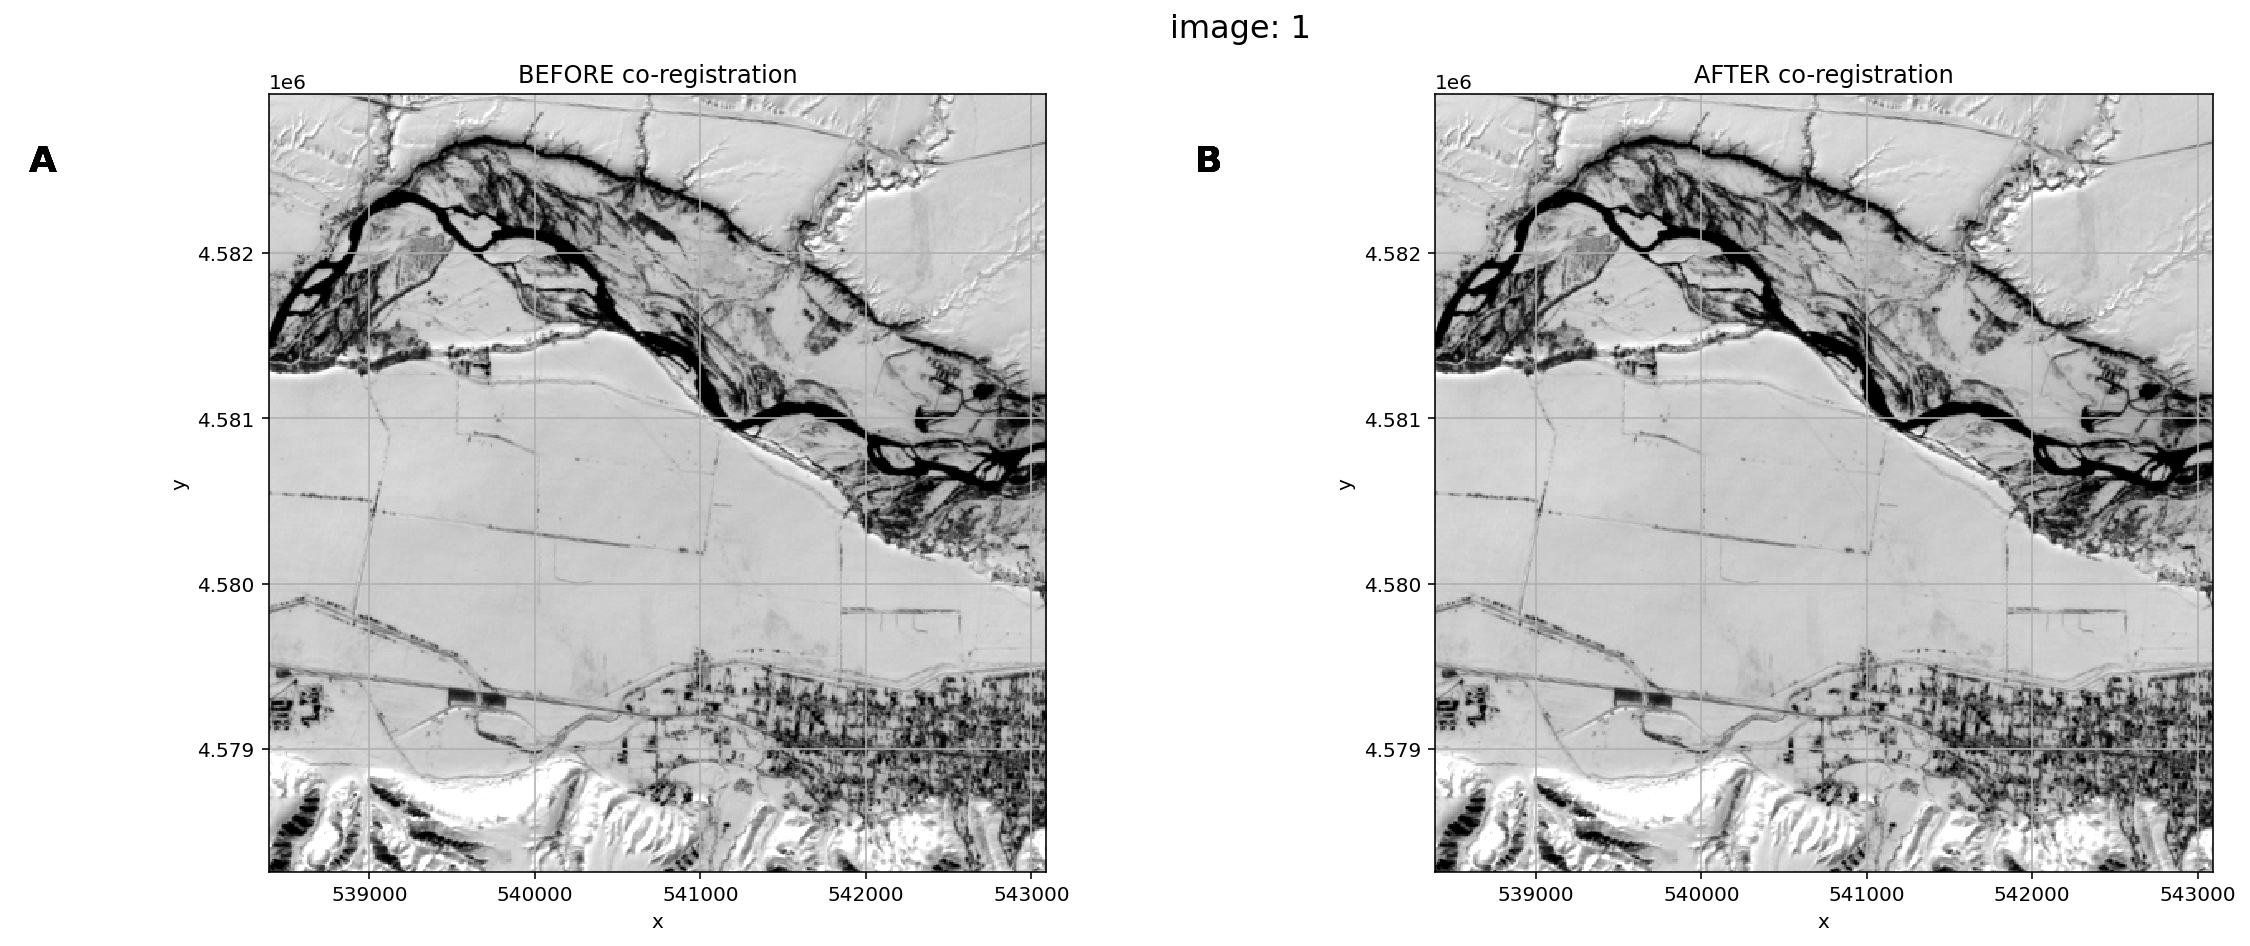
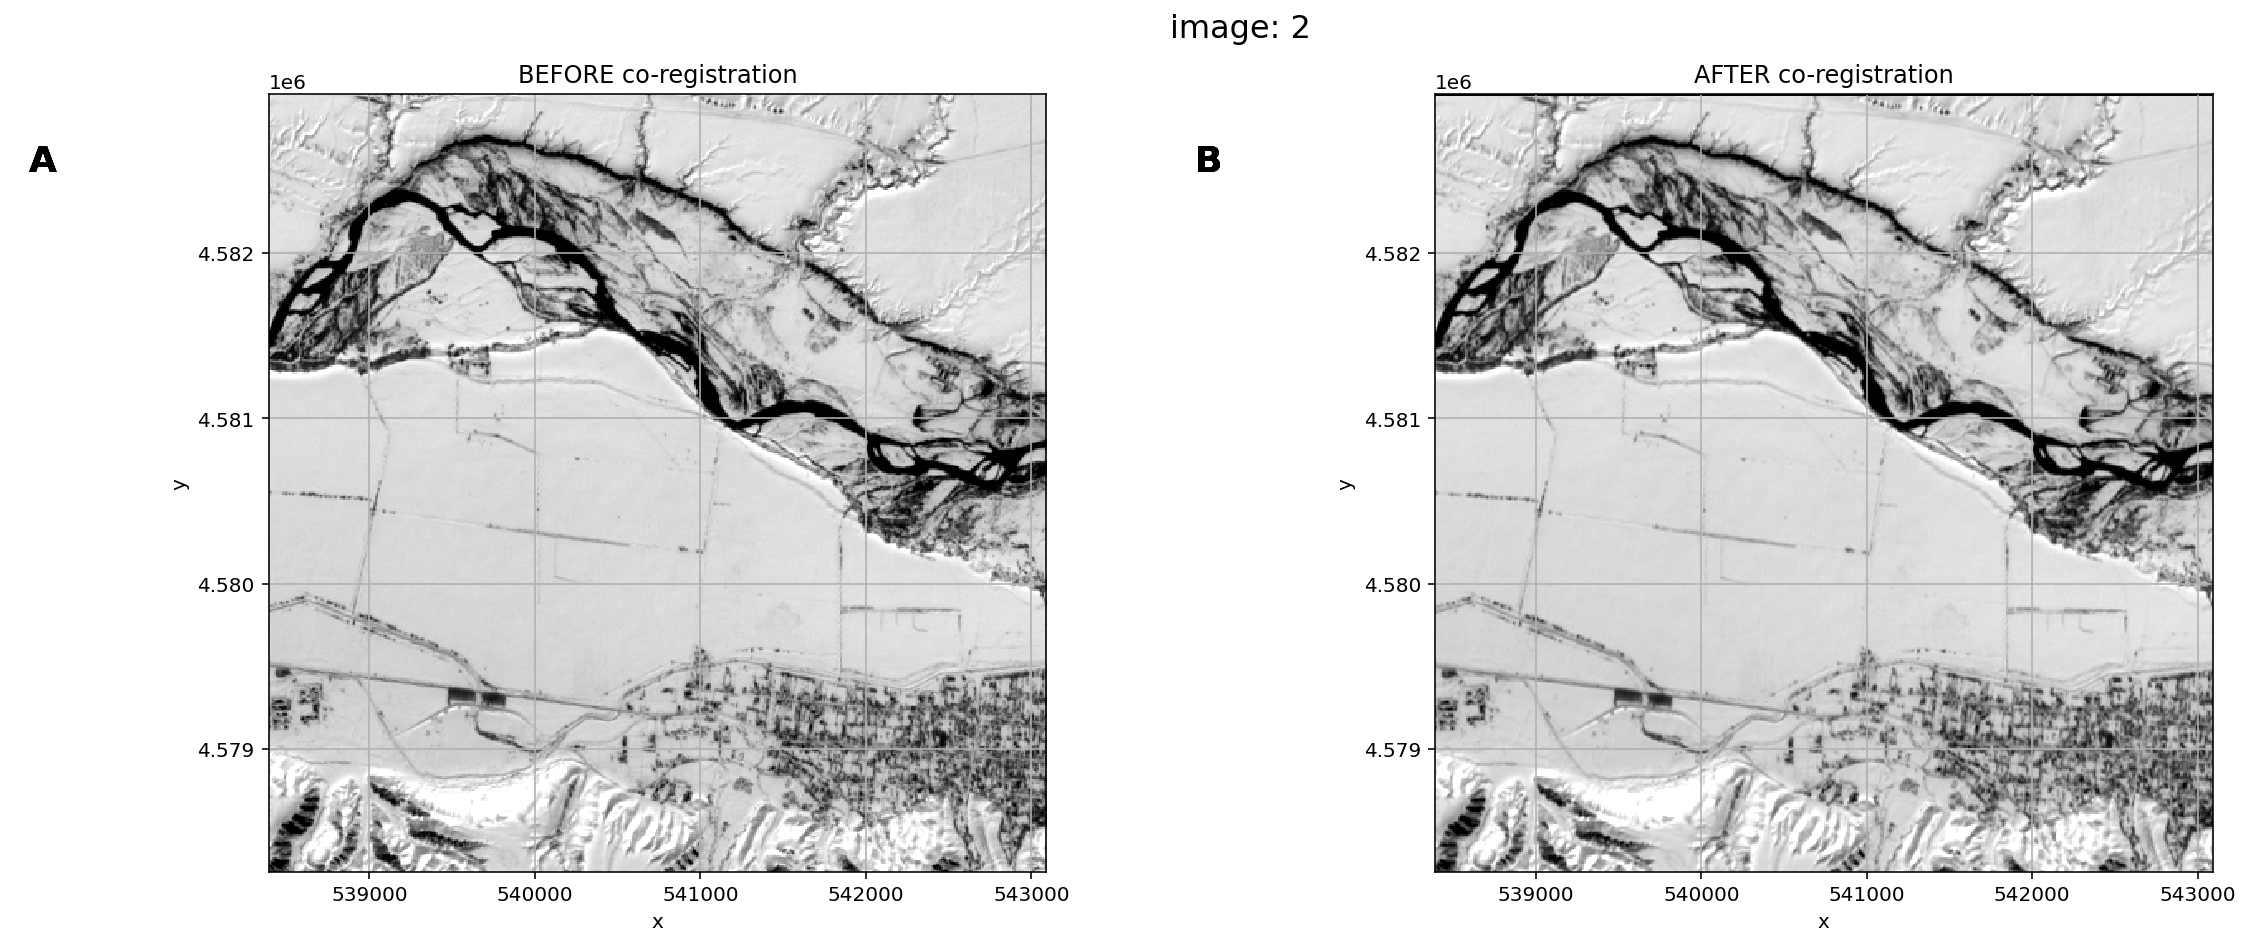
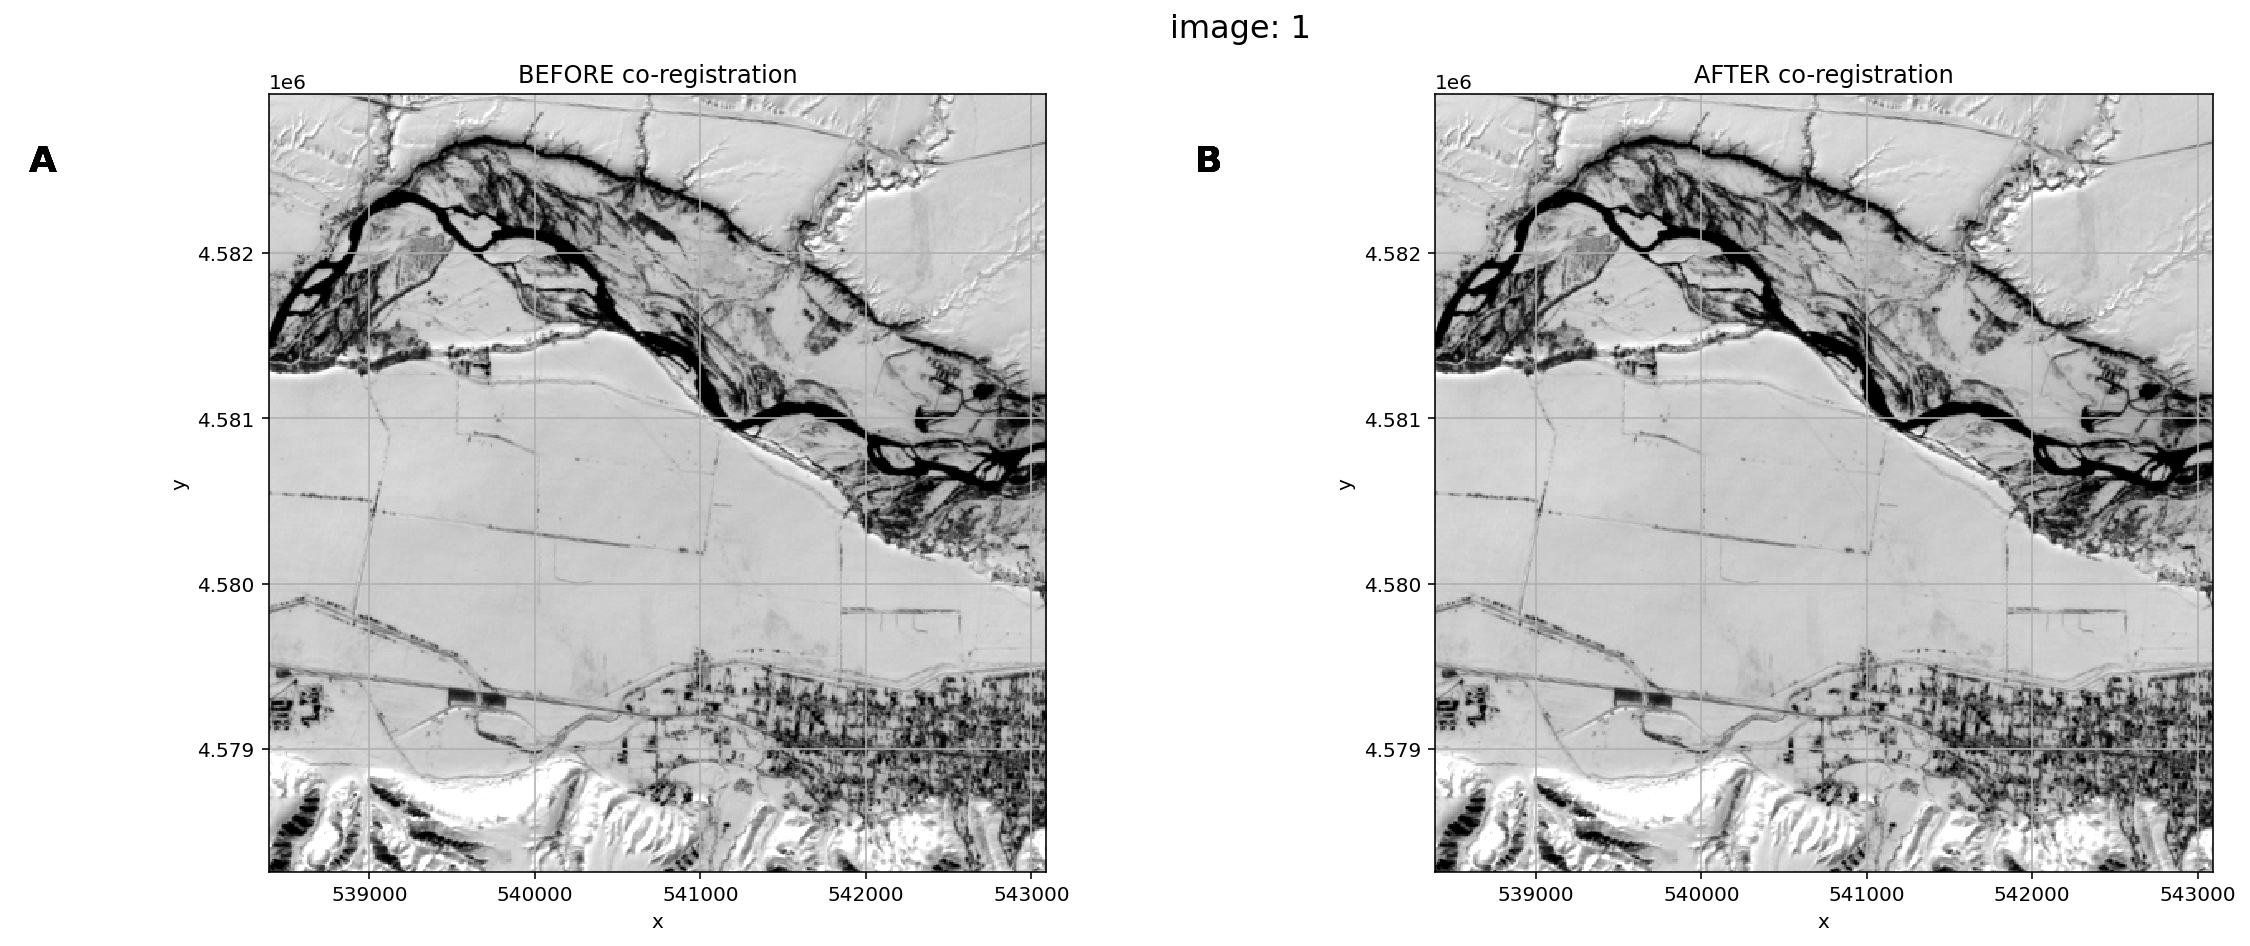

In [12]:
CR.show_matchWin(interactive=True)

In [1]:
import xarray as xr

In [2]:
stac = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_2024_masked.nc")
masked_stac = stac.Spectral_Temporal_Stack

max_cloud = 10

filtered_data = masked_stac.where(masked_stac.cloud_percentage <= max_cloud, drop=True)
filtered_data = filtered_data.rio.write_crs(masked_stac.crs, inplace=True)

#filtered_data.to_netcdf("./results/nocoregisted.nc")

In [3]:
filtered_data

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 41, band: 6, y: 470, x: 1277)> Size: 1GB
array([[[[ 7.95700000e-01,  8.40800000e-01,  8.79200000e-01, ...,
           8.60000000e-01,  8.59900000e-01,  8.48600000e-01],
         [ 7.44800000e-01,  8.08300000e-01,  8.46400000e-01, ...,
           8.46700000e-01,  8.45500000e-01,  8.57600000e-01],
         [ 6.47500000e-01,  5.83500000e-01,  6.62400000e-01, ...,
           8.33400000e-01,  8.41400000e-01,  8.56700000e-01],
         ...,
         [ 9.60600000e-01,  9.37700000e-01,  8.92000000e-01, ...,
           1.02950000e+00,  1.05920000e+00,  9.59400000e-01],
         [ 9.04000000e-01,  9.28900000e-01,  8.48600000e-01, ...,
           1.24970000e+00,  1.14880000e+00,  1.05600000e+00],
         [ 9.75100000e-01,  9.20600000e-01,  8.43900000e-01, ...,
           1.16780000e+00,  1.08320000e+00,  1.12450000e+00]],

        [[ 8.03100000e-01,  8.66500000e-01,  8.94400000e-01, ...,
           8.61700000e-01,  8.57600000e-01,  8.52700000e-01],
         [ 7.40000000e-01,  8.05500000e-01,  8.75300000e-01, ...,
           8.61600000e-01,  8.62900000e-01,  8.70300000e-01],
         [ 6.44500000e-01,  6.10200000e-01,  6.69500000e-01, ...,
           8.47300000e-01,  8.54500000e-01,  8.63200000e-01],
...
           4.21290201e-02,  7.48240390e-02,  6.63693321e-02],
         [ 9.18163673e-02,  1.07252298e-01,  9.63823607e-02, ...,
           4.65098101e-02,  5.53329355e-02,  8.03554182e-02],
         [ 1.02966000e-01,  1.19284802e-01,  1.28827878e-01, ...,
           1.57552083e-02,  2.91262136e-02,  2.89866906e-02]],

        [[-1.56756757e-01, -1.83016760e-01, -1.70422227e-01, ...,
          -2.24049080e-01, -2.19829745e-01, -2.01542416e-01],
         [-1.18791751e-01, -1.47674419e-01, -1.53358682e-01, ...,
          -2.14181642e-01, -2.20650285e-01, -2.03954214e-01],
         [-7.06610225e-02, -8.77080666e-02, -9.85147014e-02, ...,
          -2.06511176e-01, -2.19363057e-01, -2.04774536e-01],
         ...,
         [-2.09459459e-01, -2.16835994e-01, -1.93044503e-01, ...,
          -1.02796298e-01, -1.87036594e-01, -1.49364771e-01],
         [-2.01207796e-01, -2.31118683e-01, -1.81559476e-01, ...,
          -1.19210834e-01, -1.35388002e-01, -2.21712538e-01],
         [-2.17460740e-01, -2.17222222e-01, -2.06546275e-01, ...,
          -5.52587082e-02, -6.08097785e-02, -8.64729718e-02]]]],
      shape=(41, 6, 470, 1277))
Coordinates:
  * y                 (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06
  * x                 (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05
  * band              (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time              (time) datetime64[ns] 328B 2024-01-25 ... 2024-12-25
    cloud_percentage  (time) int64 328B 0 7 0 0 0 0 1 0 10 ... 0 0 0 0 1 0 0 3 0
    spatial_ref       int64 8B 0
Attributes:
    transform:  [ 1.00000e+01  0.00000e+00  5.34360e+05  0.00000e+00 -1.00000...

In [ ]:
546 458205

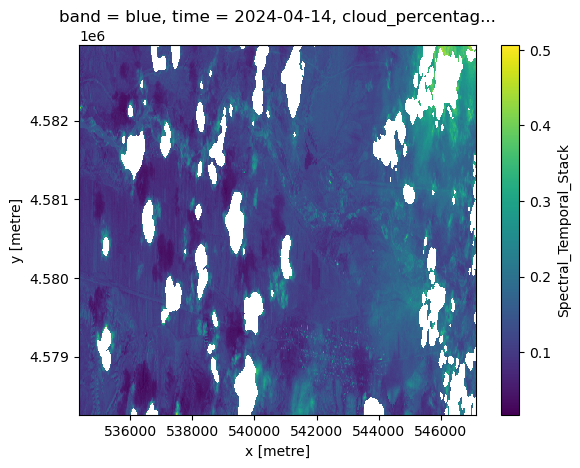

In [22]:
filtered_data[8][0].plot()

In [24]:
filtered_data[8].cloud_percentage

<xarray.DataArray 'cloud_percentage' ()> Size: 8B
array(10)
Coordinates:
    time              datetime64[ns] 8B 2024-04-14
    cloud_percentage  int64 8B 10
    spatial_ref       int64 8B 0

In [4]:
filtered_data

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 41, band: 6, y: 470, x: 1277)> Size: 1GB
array([[[[ 7.95700000e-01,  8.40800000e-01,  8.79200000e-01, ...,
           8.60000000e-01,  8.59900000e-01,  8.48600000e-01],
         [ 7.44800000e-01,  8.08300000e-01,  8.46400000e-01, ...,
           8.46700000e-01,  8.45500000e-01,  8.57600000e-01],
         [ 6.47500000e-01,  5.83500000e-01,  6.62400000e-01, ...,
           8.33400000e-01,  8.41400000e-01,  8.56700000e-01],
         ...,
         [ 9.60600000e-01,  9.37700000e-01,  8.92000000e-01, ...,
           1.02950000e+00,  1.05920000e+00,  9.59400000e-01],
         [ 9.04000000e-01,  9.28900000e-01,  8.48600000e-01, ...,
           1.24970000e+00,  1.14880000e+00,  1.05600000e+00],
         [ 9.75100000e-01,  9.20600000e-01,  8.43900000e-01, ...,
           1.16780000e+00,  1.08320000e+00,  1.12450000e+00]],

        [[ 8.03100000e-01,  8.66500000e-01,  8.94400000e-01, ...,
           8.61700000e-01,  8.57600000e-01,  8.52700000e-01],
         [ 7.40000000e-01,  8.05500000e-01,  8.75300000e-01, ...,
           8.61600000e-01,  8.62900000e-01,  8.70300000e-01],
         [ 6.44500000e-01,  6.10200000e-01,  6.69500000e-01, ...,
           8.47300000e-01,  8.54500000e-01,  8.63200000e-01],
...
           4.21290201e-02,  7.48240390e-02,  6.63693321e-02],
         [ 9.18163673e-02,  1.07252298e-01,  9.63823607e-02, ...,
           4.65098101e-02,  5.53329355e-02,  8.03554182e-02],
         [ 1.02966000e-01,  1.19284802e-01,  1.28827878e-01, ...,
           1.57552083e-02,  2.91262136e-02,  2.89866906e-02]],

        [[-1.56756757e-01, -1.83016760e-01, -1.70422227e-01, ...,
          -2.24049080e-01, -2.19829745e-01, -2.01542416e-01],
         [-1.18791751e-01, -1.47674419e-01, -1.53358682e-01, ...,
          -2.14181642e-01, -2.20650285e-01, -2.03954214e-01],
         [-7.06610225e-02, -8.77080666e-02, -9.85147014e-02, ...,
          -2.06511176e-01, -2.19363057e-01, -2.04774536e-01],
         ...,
         [-2.09459459e-01, -2.16835994e-01, -1.93044503e-01, ...,
          -1.02796298e-01, -1.87036594e-01, -1.49364771e-01],
         [-2.01207796e-01, -2.31118683e-01, -1.81559476e-01, ...,
          -1.19210834e-01, -1.35388002e-01, -2.21712538e-01],
         [-2.17460740e-01, -2.17222222e-01, -2.06546275e-01, ...,
          -5.52587082e-02, -6.08097785e-02, -8.64729718e-02]]]],
      shape=(41, 6, 470, 1277))
Coordinates:
  * y                 (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06
  * x                 (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05
  * band              (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time              (time) datetime64[ns] 328B 2024-01-25 ... 2024-12-25
    cloud_percentage  (time) int64 328B 0 7 0 0 0 0 1 0 10 ... 0 0 0 0 1 0 0 3 0
    spatial_ref       int64 8B 0
Attributes:
    transform:  [ 1.00000e+01  0.00000e+00  5.34360e+05  0.00000e+00 -1.00000...

masked_stac_da = xr.open_dataset("./results/test_masked.nc")
masked_stac = masked_stac_da.Spectral_Temporal_Stack
masked_stac

In [3]:
stac_cog = filtered_data.to_dataset(dim='band')
output_dir = './results/cogs/'

for i in range(len(stac_cog.time)):
    single_timestamp = stac_cog.isel(time=i)
    date_str = str(single_timestamp.time.values)[:10]
    print(f'Writing {date_str}')
    output_file = f'{output_dir}{date_str}.tif'    
    single_timestamp.rio.to_raster(output_file, driver='COG', dtype='float32', compress='deflate')

Writing 2024-04-06
Writing 2024-04-08
Writing 2024-04-11
Writing 2024-04-13


In [4]:
from arosics import COREG
from geoarray import GeoArray

im_reference= masked_stac[0].rio.write_crs(masked_stac.crs, inplace=True)
im_target= masked_stac[3].rio.write_crs(masked_stac.crs, inplace=True)

In [5]:
im_reference = filtered_data.sel(time="2024-02-29")
im_target = filtered_data.sel(time="2024-03-05")

In [6]:
im_reference = im_reference.transpose("y", "x", "band")
im_target = im_target.transpose("y", "x", "band")

im_reference = masked_stac[0]

im_target    = masked_stac[3]

test_img = masked_stac[0][0].rio.write_crs(masked_stac_da.spatial_ref.projected_crs_name , inplace=True)

test_img

test_img.to_netcdf('./results/testcoreg.nc')

x = xr.open_dataset("./results/testcoreg.nc")
x

im_reference[0].values

im_reference = './results/cogs/2024-04-06.tif'

im_target    = './results/cogs/2024-04-13.tif'

im_reference

im_reference

In [7]:
geotransform = im_reference.spatial_ref.GeoTransform
geotransform = [float(x) for x in geotransform.split()]

In [23]:
geotransform = im_target.spatial_ref.GeoTransform
geotransform = [float(x) for x in geotransform.split()]
geotransform

[534360.0, 10.0, 0.0, 4582960.0, 0.0, -10.0]

In [10]:
geotransform

[534360.0, 10.0, 0.0, 4582960.0, 0.0, -10.0]

In [11]:
geoArr = GeoArray(
    im_reference.values, 
    geotransform=geotransform, 
    projection=im_reference.spatial_ref.crs_wkt
)

# Now ref_prj will no longer be empty
ref_ndarray = geoArr[:]
ref_gt      = geoArr.geotransform
ref_prj     = geoArr.projection

In [12]:
geoArr = GeoArray(
    im_target.values, 
    geotransform=geotransform, 
    projection=im_reference.spatial_ref.crs_wkt
)

# Now ref_prj will no longer be empty
tgt_ndarray = geoArr[:]
tgt_gt      = geoArr.geotransform
tgt_prj     = geoArr.projection

In [13]:
geoArr_reference = GeoArray(ref_ndarray, ref_gt, ref_prj)

geoArr_target    = GeoArray(tgt_ndarray, tgt_gt, tgt_prj)

In [14]:
# try with and without alig_grids
CR = COREG(geoArr_reference, geoArr_target, path_out="./results/coregistered_test9.tif", align_grids=True)

Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(534360.0, 4578260.0, 547130.0, 4582960.0)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(534360.0, 4578260.0, 547130.0, 4582960.0)
Matching window position (X,Y): 540745.0/4580610.0


In [15]:
CR.calculate_spatial_shifts()

Detected integer shifts (X/Y):                            0/1
Detected subpixel shifts (X/Y):                           0.25557082891464233/-0.39523303508758545
Calculated total shifts in fft pixel units (X/Y):         0.25557082891464233/0.6047669649124146
Calculated total shifts in reference pixel units (X/Y):   0.25557082891464233/0.6047669649124146
Calculated total shifts in target pixel units (X/Y):      0.25557082891464233/0.6047669649124146
Calculated map shifts (X,Y):                              2.5557082891464233/-6.0476696491241455
Calculated absolute shift vector length in map units:     6.565512397684517
Calculated angle of shift vector in degrees from North:   337.09137729740405
Original map info: ['UTM', 1.0, 1.0, 534360.0, 4582960.0, 10.0, 10.0, 43, 'North', 'WGS-84']
Updated map info:  ['UTM', 1.0, 1.0, '534362.5557082891', '4582953.952330351', 10.0, 10.0, 43, 'North', 'WGS-84']
Image similarity within the matching window (SSIM before/after correction): 0.8849 => 0.942

'success'

In [16]:
result = CR.correct_shifts()

Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Correcting geometric shifts...
Writing GeoArray of size (470, 1277, 6) to ./results/coregistered_test9.tif.


In [17]:
result

OrderedDict([('band', None),
             ('is shifted', True),
             ('is resampled', True),
             ('updated map info',
              ['UTM',
               1.0,
               1.0,
               534360.0,
               4582960.0,
               10.0,
               10.0,
               43,
               'North',
               'WGS-84']),
             ('updated geotransform',
              (534360.0, 10.0, 0.0, 4582960.0, 0.0, -10.0)),
             ('updated projection',
              'PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3

In [18]:
out_geoArr = GeoArray(result["arr_shifted"], result["updated geotransform"], result["updated projection"])

In [96]:
import xarray as xr
import rioxarray
from rasterio.transform import Affine

# Convert GeoArray to NumPy array **BEFORE transposing!**
arr_shifted = out_geoArr[:]  # Extract raw data

# Ensure correct shape: (bands, height, width)
arr_shifted = arr_shifted.transpose(2, 0, 1)  # Move bands to first dimension
print("Corrected Array shape:", arr_shifted.shape)  # Should print (6, 470, 1277)

# Get spatial metadata
updated_gt = out_geoArr.geotransform
updated_projection = out_geoArr.projection

# Convert geotransform tuple to Affine
affine_transform = Affine.from_gdal(*updated_gt)

# Define xarray DataArray **after confirming shape is correct**
da = xr.DataArray(
    arr_shifted,
    dims=("band", "y", "x"),
    coords={
        "band": range(1, arr_shifted.shape[0] + 1),  # Band names from 1 to 6
        "y": range(arr_shifted.shape[1]),  # Y-dimension (470 rows)
        "x": range(arr_shifted.shape[2]),  # X-dimension (1277 columns)
    },
)

import numpy as np
da = da.where(da != 0, np.nan)

# Assign spatial reference
da = da.rio.write_transform(affine_transform)
da = da.rio.write_crs(updated_projection)

# Print result for verification
print(da)
print("CRS:", da.rio.crs)
print("Bounds:", da.rio.bounds())


Corrected Array shape: (6, 470, 1277)
<xarray.DataArray (band: 6, y: 470, x: 1277)> Size: 29MB
array([[[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [ 8.09163537e-01,  7.83168552e-01,  8.35088542e-01, ...,
          9.14638693e-01,  9.14418352e-01,  9.13609574e-01],
        [ 7.90714938e-01,  7.63670709e-01,  7.67421770e-01, ...,
          9.17331416e-01,  9.18449656e-01,  9.17654657e-01],
        ...,
        [ 9.82468444e-01,  9.71253941e-01,  9.51245683e-01, ...,
          9.45221381e-01,  1.00727482e+00,  9.58527841e-01],
        [ 9.50641303e-01,  9.55233485e-01,  9.22773126e-01, ...,
          1.13868414e+00,  1.06783513e+00,  9.88191189e-01],
        [ 9.73604661e-01,  9.52322646e-01,  9.16173834e-01, ...,
          1.12579822e+00,  1.05356093e+00,  1.00759242e+00]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        

In [93]:
da

<xarray.DataArray (band: 6, y: 470, x: 1277)> Size: 29MB
array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 8.09163537e-01,  7.83168552e-01,  8.35088542e-01, ...,
          9.14638693e-01,  9.14418352e-01,  9.13609574e-01],
        [ 7.90714938e-01,  7.63670709e-01,  7.67421770e-01, ...,
          9.17331416e-01,  9.18449656e-01,  9.17654657e-01],
        ...,
        [ 9.82468444e-01,  9.71253941e-01,  9.51245683e-01, ...,
          9.45221381e-01,  1.00727482e+00,  9.58527841e-01],
        [ 9.50641303e-01,  9.55233485e-01,  9.22773126e-01, ...,
          1.13868414e+00,  1.06783513e+00,  9.88191189e-01],
        [ 9.73604661e-01,  9.52322646e-01,  9.16173834e-01, ...,
          1.12579822e+00,  1.05356093e+00,  1.00759242e+00]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 8.10532765e-01,  8.04631673e-01,  8.51002847e-01, ...,
          9.08336094e-01,  9.08710243e-01,  9.08500803e-01],
        [ 7.69508286e-01,  7.63521498e-01,  7.64917938e-01, ...,
          9.08952739e-01,  9.11115609e-01,  9.12881163e-01],
...
         -1.44593127e-02, -2.57701084e-02, -1.04277151e-02],
        [-1.32834988e-02, -1.14497482e-02, -1.67693064e-02, ...,
         -2.19277990e-02, -8.40724725e-03, -5.65642437e-03],
        [-1.85145573e-02, -1.25895365e-02, -1.68599580e-02, ...,
         -1.44392128e-02, -6.59437934e-03, -8.08776702e-03]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-6.51609683e-03, -1.22580755e-02, -1.50522023e-02, ...,
          6.42563696e-04,  9.92976907e-04,  1.11498255e-03],
        [ 1.93865256e-02,  1.12327958e-02, -1.20619620e-02, ...,
          8.76755539e-04,  1.00597535e-03,  2.21007537e-03],
        ...,
        [ 3.73537081e-03,  9.56895483e-03,  7.69454846e-03, ...,
          5.81566002e-04,  1.06514403e-02, -1.06186636e-02],
        [ 2.15726025e-03,  7.96959550e-03,  1.27993966e-02, ...,
          6.31925230e-03, -1.42892085e-02, -1.71258104e-02],
        [ 5.32719772e-03,  1.04221041e-02,  1.01307471e-02, ...,
         -3.71987946e-03, -1.51016557e-02, -1.30339878e-02]]],
      shape=(6, 470, 1277))
Coordinates:
  * band         (band) int64 48B 1 2 3 4 5 6
  * y            (y) int64 4kB 0 1 2 3 4 5 6 7 ... 463 464 465 466 467 468 469
  * x            (x) int64 10kB 0 1 2 3 4 5 6 ... 1271 1272 1273 1274 1275 1276
    spatial_ref  int64 8B 0

In [77]:
print("Original shape of arr_shifted:", arr_shifted.shape)

Original shape of arr_shifted: (6, 470, 1277)


In [97]:
da.to_netcdf("./results/anothertrash6.nc")

geoArr  = GeoArray(im_reference)
ref_ndarray = geoArr[:]            # numpy.ndarray with shape (10980, 10980)
ref_gt      = geoArr.geotransform  # GDAL geotransform: (300000.0, 10.0, 0.0, 5900040.0, 0.0, -10.0)
ref_prj     = geoArr.projection    # projection as WKT string ('PROJCS["WGS 84 / UTM zone 33N....')

ref_gt

geoArr  = GeoArray(im_target)

tgt_ndarray = geoArr[:]            # numpy.ndarray with shape (10980, 10980)

tgt_gt      = geoArr.geotransform  # GDAL geotransform: (300000.0, 10.0, 0.0, 5900040.0, 0.0, -10.0)

tgt_prj     = geoArr.projection    # projection as WKT string ('PROJCS["WGS 84 / UTM zone 33N....')

geoArr_reference = GeoArray(ref_ndarray, ref_gt, ref_prj)

geoArr_target    = GeoArray(tgt_ndarray, tgt_gt, tgt_prj)

# try with and without alig_grids
CR = COREG(geoArr_reference, geoArr_target, path_out="./results/coregistered_test7.tif", align_grids=True)

CR.calculate_spatial_shifts()

CR.correct_shifts()

ord_dic = CR.correct_shifts()
new_img = ord_dic['arr_shifted']

new_img

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/numpy/ma/core.py:502: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/numpy/ma/core.py:502: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/numpy/ma/core.py:502: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)


Matching window before and after correction (left and right): 


:Layout
   .Image.I  :HoloMap   [image]
      :Image   [x,y]   (z)
   .Image.II :HoloMap   [image]
      :Image   [x,y]   (z)
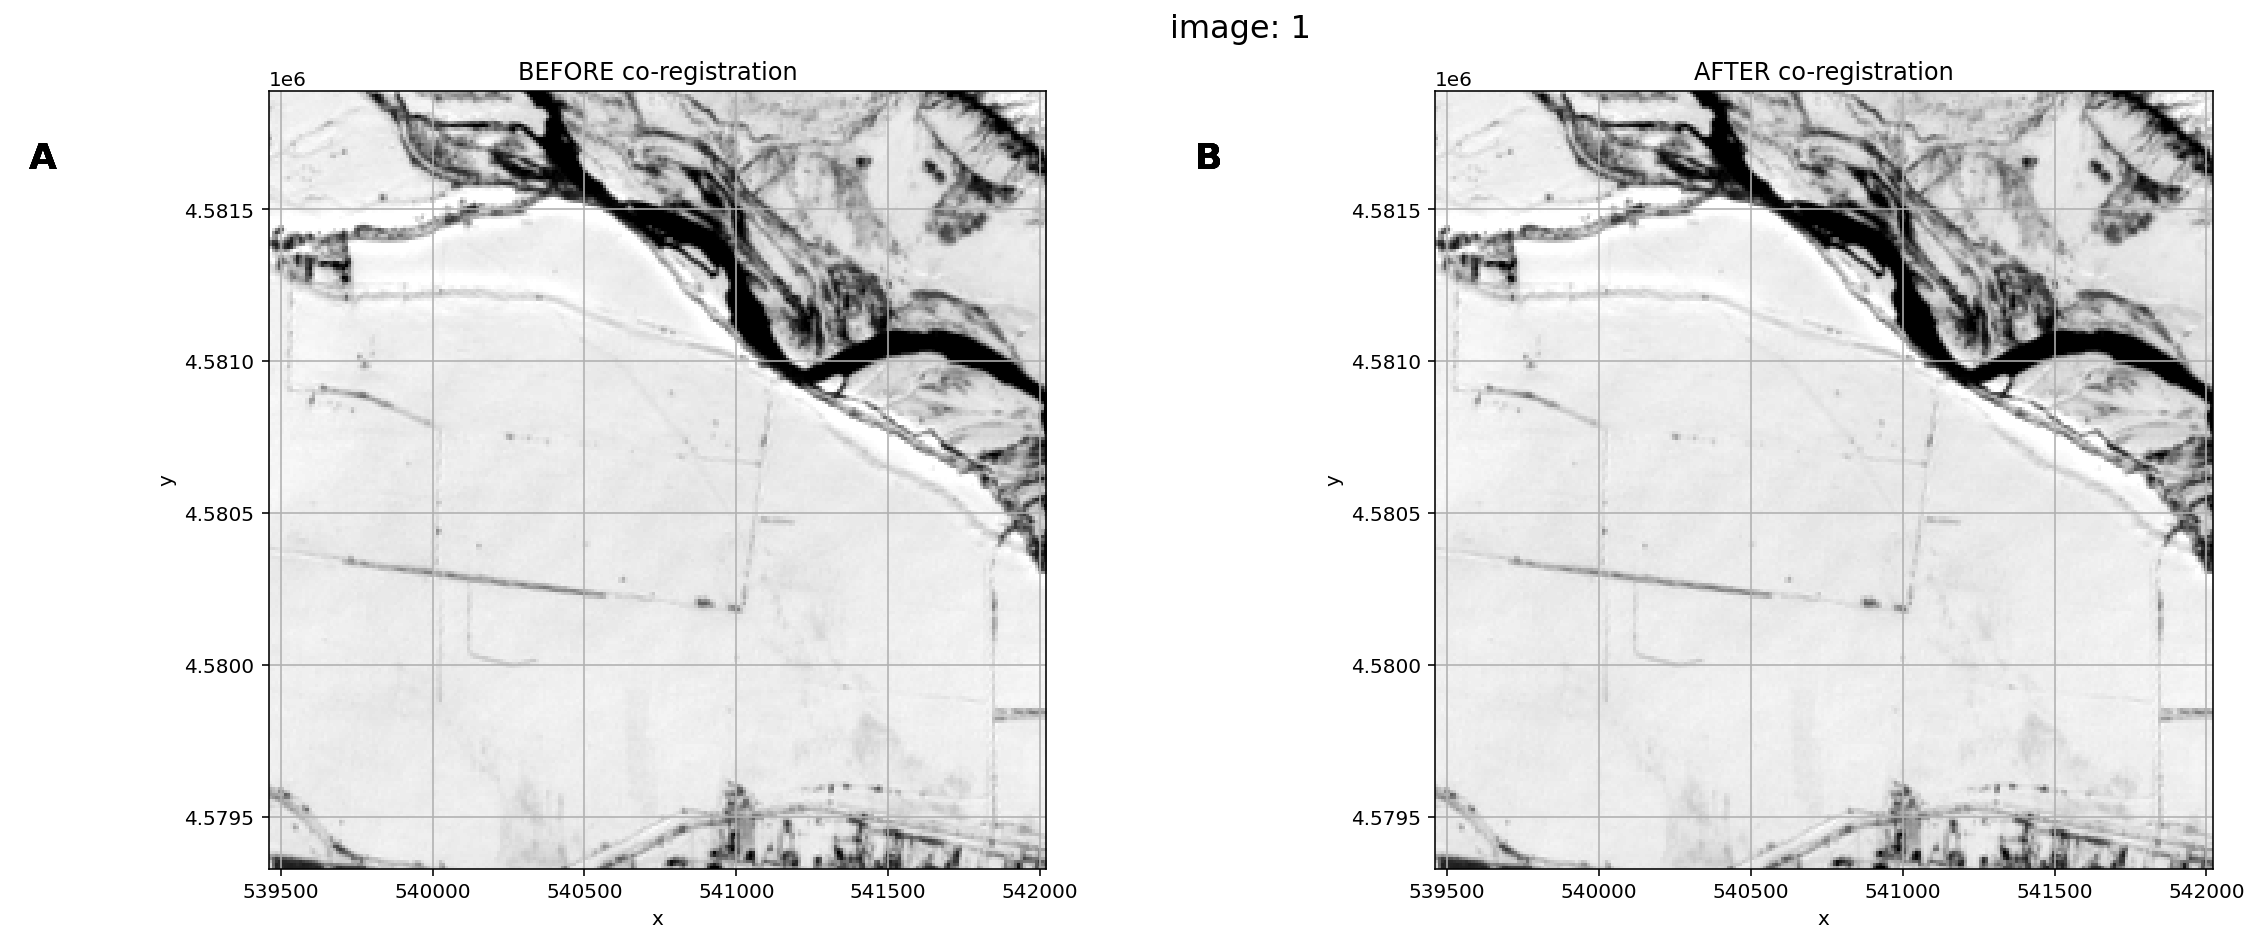
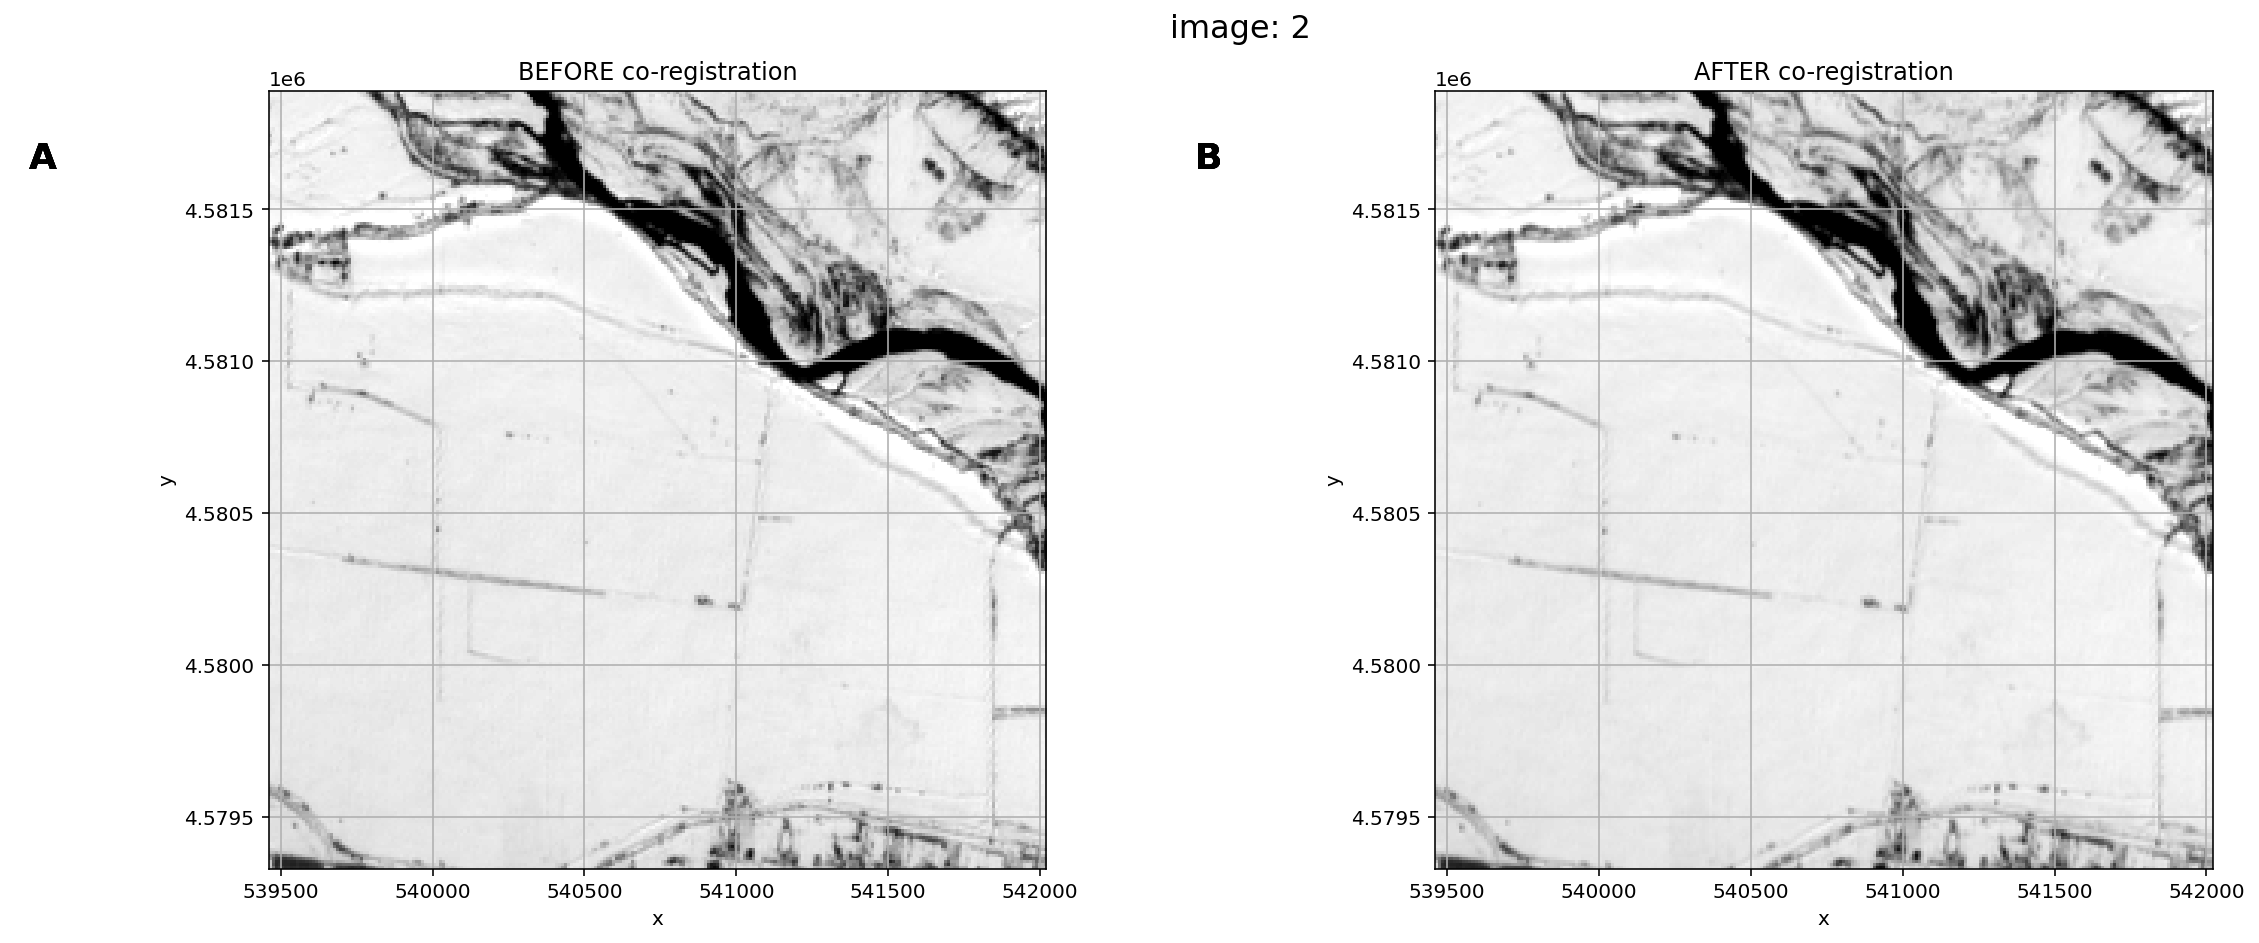
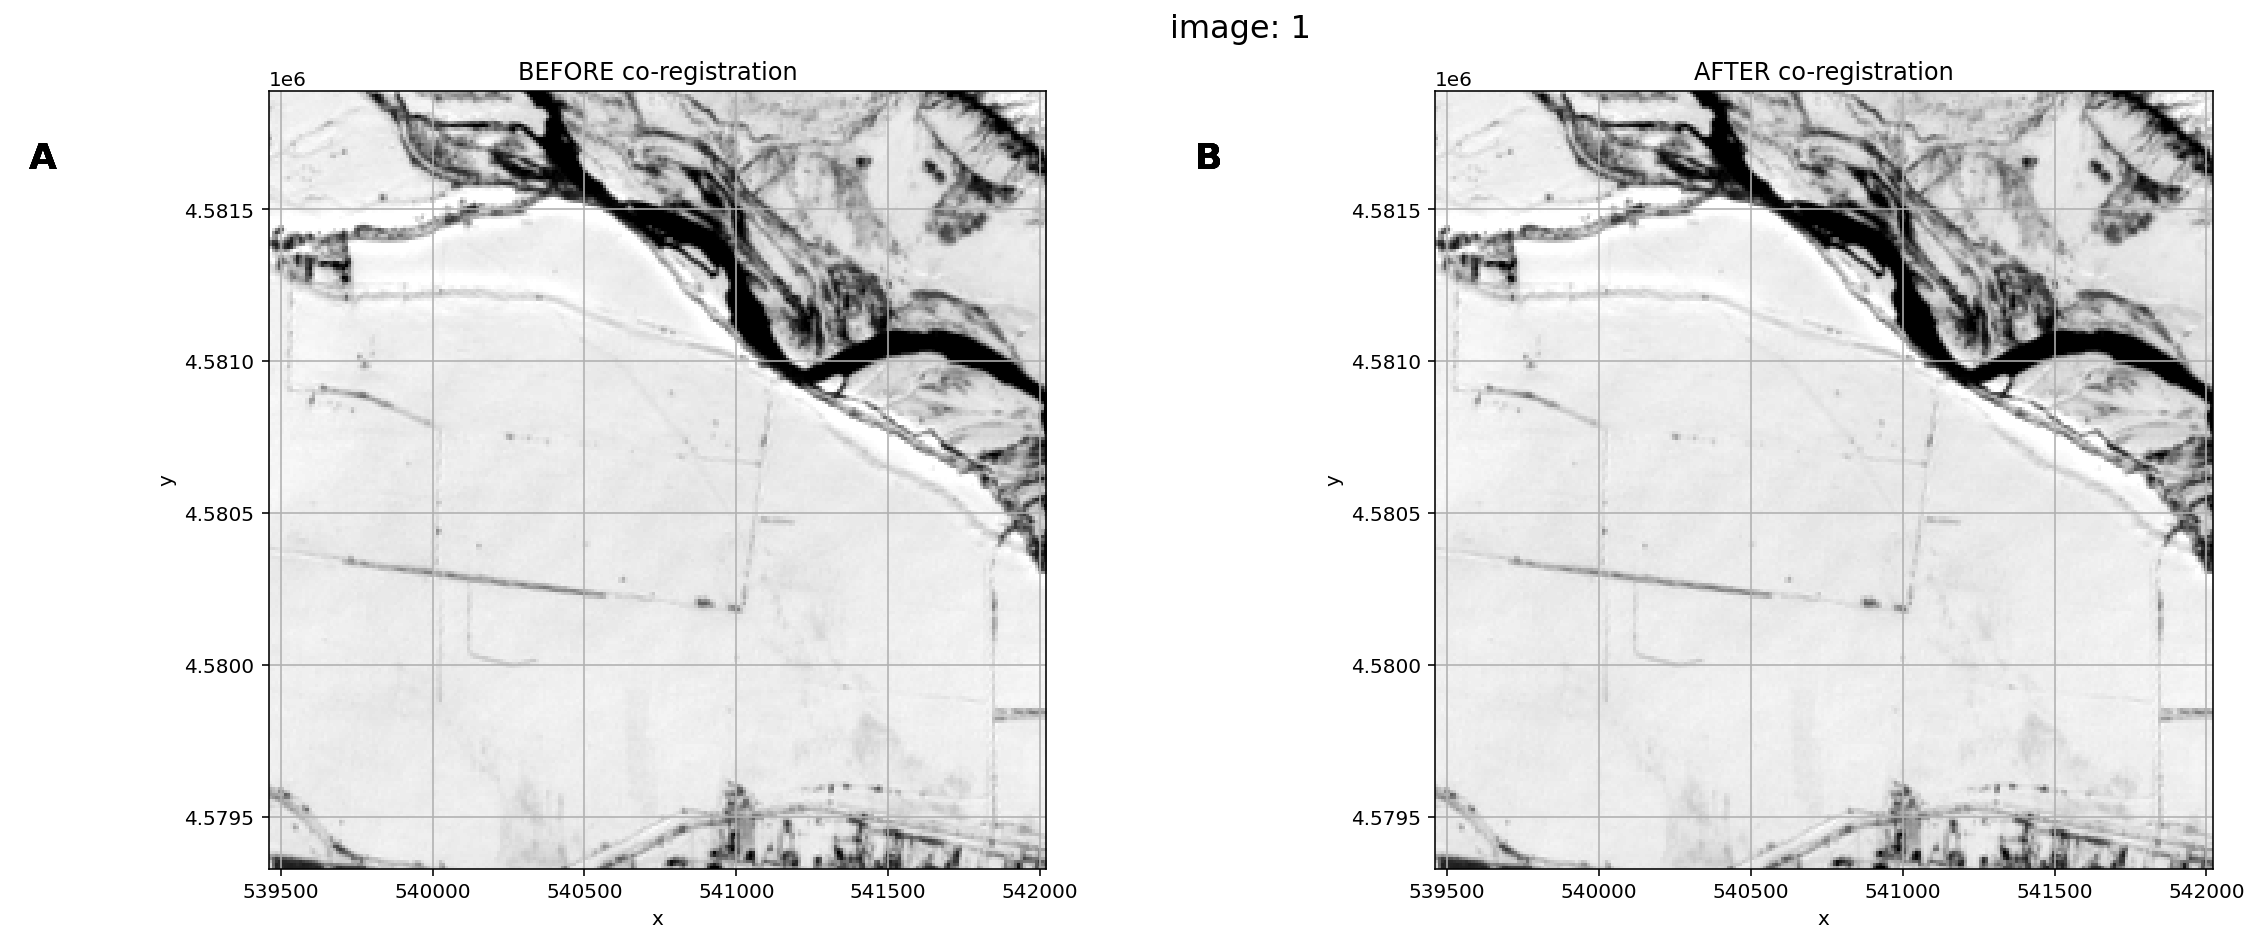

In [22]:
CR.show_matchWin(interactive=True)

In [45]:
import rasterio
import matplotlib.pyplot as plt

# Open the corrected TIFF file
with rasterio.open("./results/coregistered_test3.tif") as src:
    # Read the first band (if the image is multi-band, adjust as needed)
    image = src.read(1)
    
# Plot the image using matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(image, cmap='gray')  # You can change the colormap if needed
plt.colorbar(label='Pixel values')
plt.title("Corrected TIFF Image")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.show()

In [46]:
x = xr.open_dataset("./results/coregistered_test.nc")


ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'rasterio']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [20]:
from arosics import COREG_LOCAL

im_reference = './results/cogs/2024-04-06.tif'

im_target    = './results/cogs/2024-04-13.tif'

kwargs = {

    'grid_res'     : 200,

    'window_size'  : (256, 256),

    'path_out'     : 'auto',

    'projectDir'   : 'my_project',

    'q'            : False,

}

CRL = COREG_LOCAL(im_reference,im_target,**kwargs)

CRL.correct_shifts()

Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(667020.0, 4544150.0, 672130.0, 4546620.0)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(667020.0, 4544150.0, 672130.0, 4546620.0)
Matching window position (X,Y): 669575.0/4545385.0
Target window size (256, 256) not possible due to too small overlap area or window position too close to an image edge. New matching window size: (256, 247).
Initializing tie points grid...
Calculating tie point grid (6 points) using 160 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:15
/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/arosics/Tie_Point_Grid.py:404: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  GDF = GDF.fillna(self.outFillVal)
/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/arosics/Tie_Point_Grid.py:1179: UserWarning: RANSAC filtering could not be applied because there were too few tie points to fit a model.
  warn('RANSAC filtering could not be applied '
Translating progress |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==============================================----| 91.1% Complete  => 0:00:00

Found 6 matches.
Performing validity checks...
0 tie points flagged by level 1 filtering (reliability).
1 tie points flagged by level 2 filtering (SSIM).
0 tie points flagged by level 3 filtering (RANSAC)
5 valid tie points remain after filtering.
Correcting geometric shifts...


Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Writing GeoArray of size (247, 511, 6) to /dss/dsshome1/08/di38red/terrabyte_cube/interactive/my_project/2024-04-13__shifted_to__2024-04-06.bsq.


/dss/dsshome1/08/di38red/micromamba/envs/arosics/lib/python3.12/site-packages/geoarray/baseclasses.py:1112: UserWarning: Band-specific nodata values are not supported by the ENVI header format.
  warnings.warn("Band-specific nodata values are not supported "


OrderedDict([('band', None),
             ('is shifted', True),
             ('is resampled', True),
             ('updated map info',
              ['UTM',
               1.0,
               1.0,
               667020.0,
               4546620.0,
               10.0,
               10.0,
               35,
               'North',
               'WGS-84']),
             ('updated geotransform',
              (667020.0, 10.0, 0.0, 4546620.0, 0.0, -10.0)),
             ('updated projection',
              'PROJCS["WGS 84 / UTM zone 35N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",27],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT

In [22]:
CRL.view_CoRegPoints(figsize=(15,15), backgroundIm='ref')

In [3]:
import xarray as xr
stac = xr.open_dataset("./results/coregoutput3.nc")
stac = stac.Spectral_Temporal_Stack

In [4]:
stac

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 40, band: 6, y: 470, x: 1277)> Size: 1GB
[144045600 values with dtype=float64]
Coordinates:
  * band              (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time              (time) datetime64[ns] 320B 2024-01-25 ... 2024-12-25
    cloud_percentage  int64 8B ...
  * y                 (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06
  * x                 (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05
Attributes:
    transform:     [ 1.00000e+01  0.00000e+00  5.34360e+05  0.00000e+00 -1.00...
    grid_mapping:  spatial_ref

In [2]:
from stac2ardcube import interactive_time_view
from stac2ardcube import generate_animation

In [5]:
interactive_time_view(stac, 'rgb', widget_type='slider')

interactive(children=(IntSlider(value=0, description='Time', layout=Layout(width='800px'), max=39), Output()),…

In [7]:
interactive_time_view(stac, 'rgb', widget_type='dropdown')

interactive(children=(Dropdown(description='Date:', layout=Layout(width='300px'), options=(('25-01-2024', 0), …

MovieWriter imagemagick unavailable; using Pillow instead.


Number of images: 40


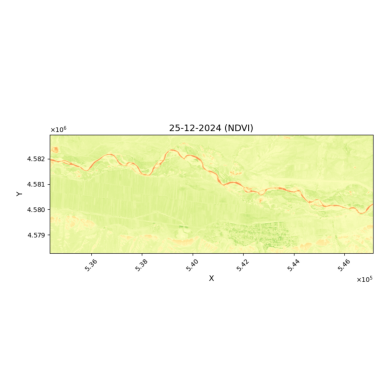

In [4]:
generate_animation(stac, "./animations", "ndvi")